# 13 — Anomalous identity diagnostic (`pEAB9GS`)

The trust-window evaluation returned an **inverted** result for one participant:

| modality | AUC @ k=1 | AUC @ k=20 |
|---|---|---|
| tap | 0.036 | 0.000 |
| motion | 0.001 | 0.000 |
| gesture | 0.444 | — |

An AUC of 0.000 is not weak performance or noise. It means *every* impostor
comparison scored closer than *every* genuine one: this participant's probe
session sits further from their own enrolment reference than from every other
identity's. It is consistent across two independent modalities (tap and
motion), which rules out a single-family feature bug.

Their split assignment is structurally clean — three sessions, sequential
`sessionIndex` 2/3/4, all `localStorage_p2_returning`, all mobile — so this is
not a role-assignment error.

Two explanations worth separating, and they have very different consequences:

1. **Within-sitting change.** `pEAB9GS` is the only participant whose sessions
   were all recorded in one sitting (~1.3h apart, vs ~24h+ for everyone else).
   Something physical may have changed between them — posture, hand use,
   device held vs propped.
2. **More than one person used the same browser.** `participantId` is a
   localStorage token, so it identifies a *browser profile*, not a person. If
   two people shared it, this is a genuine same-device-different-person case
   occurring naturally in the dataset — which is precisely the threat model
   the whole project is built around.

This notebook is diagnostic, not a verdict engine: it lays out what the data
shows, names what it cannot settle, and ends with open questions.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

TARGET  = 'pUNKH7L'
CONTROL = 'p3M6E7Z'

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling'))
splits = pd.read_csv(MOD_DIR / 'identity_splits.csv')
raw_path = find('data/processed/raw_events.parquet', '../data/processed/raw_events.parquet')

mods = {m: pd.read_parquet(MOD_DIR / f'{m}_windows.parquet')
        for m in ['tap', 'gesture', 'motion', 'typing']}
print({m: d.shape for m, d in mods.items()})
print(f"\nTARGET={TARGET}  CONTROL={CONTROL}")


{'tap': (3324, 109), 'gesture': (3324, 117), 'motion': (3291, 40), 'typing': (684, 168)}

TARGET=pUNKH7L  CONTROL=p3M6E7Z


## 1. Session structure and timing

First: is this participant's session layout unusual in a way that alone explains the result?

In [3]:
print(splits[splits['participantId'].isin([TARGET, CONTROL])].to_string(index=False))

participantId                        sessionId  sessionIndex  session_position  n_sessions_for_participant  role  n_windows deviceFamily            identitySource  evaluable
      p3M6E7Z d8efac44560c4faaba639beb6d1cbfca             1                 1                           3 train        126       mobile localStorage_p2_returning       True
      p3M6E7Z 5d96fed676874483a08dbfc88f0fa0d2             3                 2                           3 enrol         69       mobile localStorage_p2_returning       True
      p3M6E7Z 8bac21c8f52541ceaf231a4c44a89108             4                 3                           3 probe         70       mobile localStorage_p2_returning       True
      pUNKH7L 49a146ebd04d41a883eeeecc9c02d076             1                 1                           3 train         46       mobile localStorage_p2_returning       True
      pUNKH7L 403e8f08544c47b083f7dde8490cd145             2                 2                           3 enrol        131       

In [4]:
ctx_cols = ['ctxTimeOfDay','ctxFatigue','ctxFocusLevel','ctxEnvironmentNoise','ctxMovement',
            'ctxPosture','ctxHandUse','ctxInputDevice','ctxCaffeine','ctxAlcohol','ctxPrivacy',
            'deviceModel','devicePlatform','sessionDurationMs','sessionIndex']
raw_ctx = pd.read_parquet(raw_path, columns=['sessionId','participantId','timestampIso'] + ctx_cols)

sess_ctx = (raw_ctx[raw_ctx['participantId'].isin([TARGET, CONTROL])]
            .groupby(['participantId','sessionId']).first().reset_index())
sess_ctx['started'] = pd.to_datetime(sess_ctx['timestampIso'], format='mixed', utc=True)
sess_ctx = sess_ctx.sort_values(['participantId','started'])
sess_ctx['gap_hours'] = sess_ctx.groupby('participantId')['started'].diff().dt.total_seconds()/3600
print(sess_ctx[['participantId','sessionId','started','gap_hours','sessionDurationMs']].to_string(index=False))


participantId                        sessionId                          started  gap_hours  sessionDurationMs
      p3M6E7Z d8efac44560c4faaba639beb6d1cbfca 2026-07-28 16:46:20.104000+00:00        NaN             955902
      p3M6E7Z 5d96fed676874483a08dbfc88f0fa0d2 2026-09-01 18:39:36.351000+00:00 841.887846             526892
      p3M6E7Z 8bac21c8f52541ceaf231a4c44a89108 2026-09-04 15:41:37.559000+00:00  69.033669             533410
      pUNKH7L 49a146ebd04d41a883eeeecc9c02d076 2026-07-31 07:29:09.915000+00:00        NaN             359543
      pUNKH7L 403e8f08544c47b083f7dde8490cd145 2026-08-05 13:40:18.431000+00:00 126.185699             991640
      pUNKH7L f7309697facd4ea6885b5b3f3d5e744f 2026-08-08 11:44:17.090000+00:00  70.066294             185817


### Context answers across the target's sessions

The participant re-answers the context questionnaire at the start of every
session. If posture / hand use / movement changed between sessions, that is a
concrete, self-reported explanation for a behavioural shift — and it is
recorded rather than inferred. If every answer is identical, that removes the
simplest benign explanation.

In [5]:
show = ['sessionId','ctxPosture','ctxHandUse','ctxMovement','ctxFatigue','ctxFocusLevel',
        'ctxEnvironmentNoise','ctxPrivacy','ctxTimeOfDay','deviceModel']
for pid in [TARGET, CONTROL]:
    print(f"=== {pid} ===")
    print(sess_ctx[sess_ctx['participantId']==pid][show].to_string(index=False))
    print()


=== pUNKH7L ===
                       sessionId ctxPosture ctxHandUse ctxMovement  ctxFatigue  ctxFocusLevel ctxEnvironmentNoise ctxPrivacy ctxTimeOfDay  deviceModel
49a146ebd04d41a883eeeecc9c02d076    sitting two_handed        none           3              3              normal    private      morning older_iphone
403e8f08544c47b083f7dde8490cd145    sitting two_handed        none           3              3               quiet    private      morning older_iphone
f7309697facd4ea6885b5b3f3d5e744f    sitting two_handed        none           2              3               quiet    private    afternoon older_iphone

=== p3M6E7Z ===
                       sessionId ctxPosture       ctxHandUse ctxMovement  ctxFatigue  ctxFocusLevel ctxEnvironmentNoise  ctxPrivacy ctxTimeOfDay    deviceModel
d8efac44560c4faaba639beb6d1cbfca    sitting one_handed_right        none           4              3              normal shared_room      evening iphone_16_plus
5d96fed676874483a08dbfc88f0fa0d2    sitting

In [6]:
# Which context fields actually CHANGE within each participant? A field that
# varies across the target's sessions but not the control's is a candidate
# explanation; one that varies for both is normal session-to-session noise.
varying = {}
for pid in [TARGET, CONTROL]:
    sub = sess_ctx[sess_ctx['participantId']==pid]
    varying[pid] = {c: sub[c].nunique() for c in ctx_cols if c in sub.columns}
print(pd.DataFrame(varying).rename(columns={TARGET:'target_n_distinct', CONTROL:'control_n_distinct'})
      .sort_values('target_n_distinct', ascending=False).to_string())


                     target_n_distinct  control_n_distinct
sessionDurationMs                    3                   3
sessionIndex                         3                   3
ctxTimeOfDay                         2                   2
ctxFatigue                           2                   2
ctxEnvironmentNoise                  2                   2
ctxCaffeine                          2                   1
ctxFocusLevel                        1                   1
ctxMovement                          1                   1
ctxPosture                           1                   1
ctxHandUse                           1                   2
ctxInputDevice                       1                   1
ctxAlcohol                           1                   1
ctxPrivacy                           1                   2
deviceModel                          1                   2
devicePlatform                       1                   1


## 2. Reproducing the inversion

Rebuild the raw-distance scoring exactly as `evaluate_trust_windows.py` does,
so what follows is diagnosing the *same* number, not a lookalike computed a
different way.

In [7]:
ID = {'sessionId','participantId','deviceFamily','window_index','window_start_s','window_end_s',
      'taskIndex','taskType','activeArea','task_pass','task_start_s','task_end_s','role'}

def score_table(modality):
    df = mods[modality]
    df = df[df['deviceFamily']=='mobile'].merge(splits[['sessionId','role']], on='sessionId', how='inner')
    feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
    feats = [c for c in feats if df[c].notna().mean() >= 0.5]
    tr = df[df['role']=='train']
    basis = tr if len(tr) >= 30 else df
    imp = SimpleImputer(strategy='median').fit(basis[feats])
    sc  = StandardScaler().fit(imp.transform(basis[feats]))
    T = lambda s: sc.transform(imp.transform(s[feats]))
    refs = {p: T(g).mean(axis=0) for p, g in df[df['role']=='enrol'].groupby('participantId')}
    rows = []
    for pid, g in df[df['role']=='probe'].groupby('participantId'):
        g = g.sort_values('window_start_s'); X = T(g)
        for i in range(len(g)):
            for cand, ref in refs.items():
                rows.append({'probe_pid':pid,'cand':cand,'genuine':int(cand==pid),
                             'dist':float(np.linalg.norm(X[i]-ref)),
                             'window_start_s':g.iloc[i]['window_start_s']})
    return pd.DataFrame(rows), feats, T, df, refs

scores = {}
for m in ['tap','gesture','motion']:
    s, feats, T, df_m, refs_m = score_table(m)
    scores[m] = s
    sub = s[s['probe_pid']==TARGET]
    own = sub[sub['genuine']==1]['dist']
    oth = sub[sub['genuine']==0]['dist']
    print(f"{m:8s}  {TARGET}: median distance to OWN enrolment = {own.median():.2f}, "
          f"to others = {oth.median():.2f}  -> "
          f"{'INVERTED' if own.median() > oth.median() else 'normal'}")


tap       pUNKH7L: median distance to OWN enrolment = 11.16, to others = 11.68  -> normal
gesture   pUNKH7L: median distance to OWN enrolment = 7.33, to others = 7.97  -> normal
motion    pUNKH7L: median distance to OWN enrolment = 6.71, to others = 7.04  -> normal


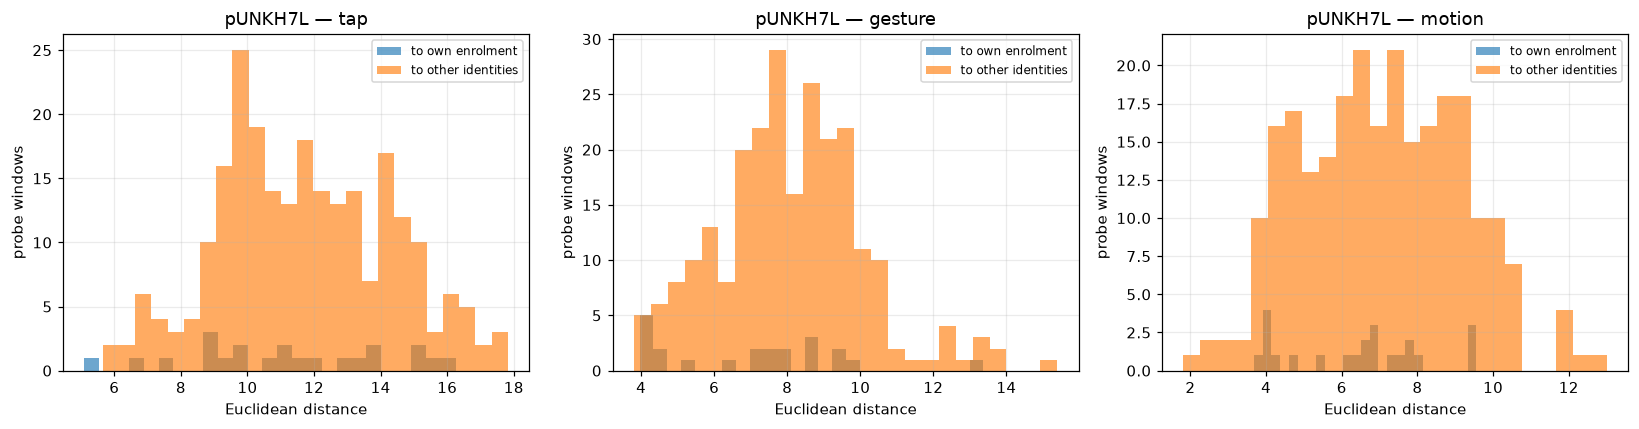

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ['tap','gesture','motion']):
    sub = scores[m][scores[m]['probe_pid']==TARGET]
    ax.hist(sub[sub['genuine']==1]['dist'], bins=25, alpha=0.65, label='to own enrolment')
    ax.hist(sub[sub['genuine']==0]['dist'], bins=25, alpha=0.65, label='to other identities')
    ax.set_title(f'{TARGET} — {m}'); ax.set_xlabel('Euclidean distance'); ax.set_ylabel('probe windows')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


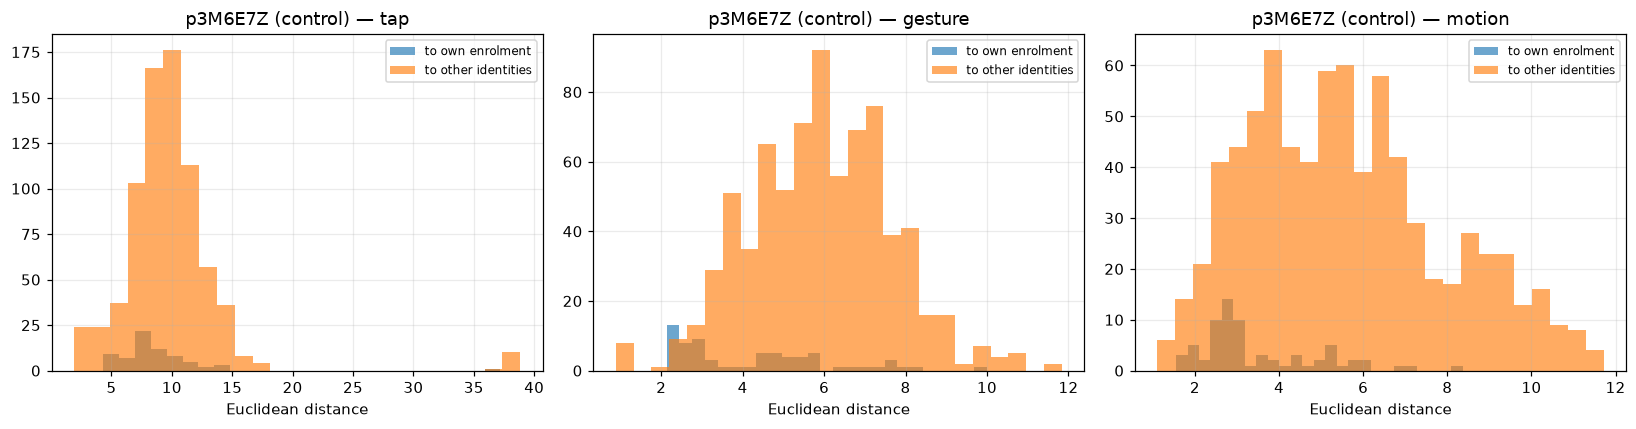

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ['tap','gesture','motion']):
    sub = scores[m][scores[m]['probe_pid']==CONTROL]
    ax.hist(sub[sub['genuine']==1]['dist'], bins=25, alpha=0.65, label='to own enrolment')
    ax.hist(sub[sub['genuine']==0]['dist'], bins=25, alpha=0.65, label='to other identities')
    ax.set_title(f'{CONTROL} (control) — {m}'); ax.set_xlabel('Euclidean distance')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 3. Who is the target being mistaken for?

If the probe session resembles one *specific* other identity, that is a
different story from resembling everyone-in-general. Resembling one person
strongly would be striking; being generically far from its own reference
points instead at a within-person change.

In [10]:
for m in ['tap','gesture','motion']:
    sub = scores[m][scores[m]['probe_pid']==TARGET]
    rank = sub.groupby('cand')['dist'].median().sort_values()
    own_rank = list(rank.index).index(TARGET) + 1
    print(f"=== {m} === (own reference ranks {own_rank} of {len(rank)}, lower=closer)")
    print(rank.round(2).to_string())
    print()


=== tap === (own reference ranks 4 of 12, lower=closer)
cand
pAFQRTM    10.13
pWS9VTN    10.67
pEZVKTS    10.73
pUNKH7L    11.16
pG5G4MS    11.33
p3YDMHG    11.45
pH3S4X4    11.50
pA6XL23    11.71
pNDG8LJ    11.86
p3M6E7Z    11.88
pEAB9GS    12.48
p95MPVX    12.75

=== gesture === (own reference ranks 2 of 12, lower=closer)
cand
p95MPVX    7.12
pUNKH7L    7.33
pG5G4MS    7.34
pAFQRTM    7.47
p3M6E7Z    7.59
p3YDMHG    7.63
pWS9VTN    7.75
pEZVKTS    8.09
pH3S4X4    8.25
pNDG8LJ    8.61
pEAB9GS    8.77
pA6XL23    8.93

=== motion === (own reference ranks 7 of 12, lower=closer)
cand
pA6XL23     5.33
pAFQRTM     6.20
pNDG8LJ     6.37
pEAB9GS     6.49
pWS9VTN     6.60
pG5G4MS     6.66
pUNKH7L     6.71
p3M6E7Z     6.97
pH3S4X4     7.30
p95MPVX     7.43
pEZVKTS     7.81
p3YDMHG    10.18



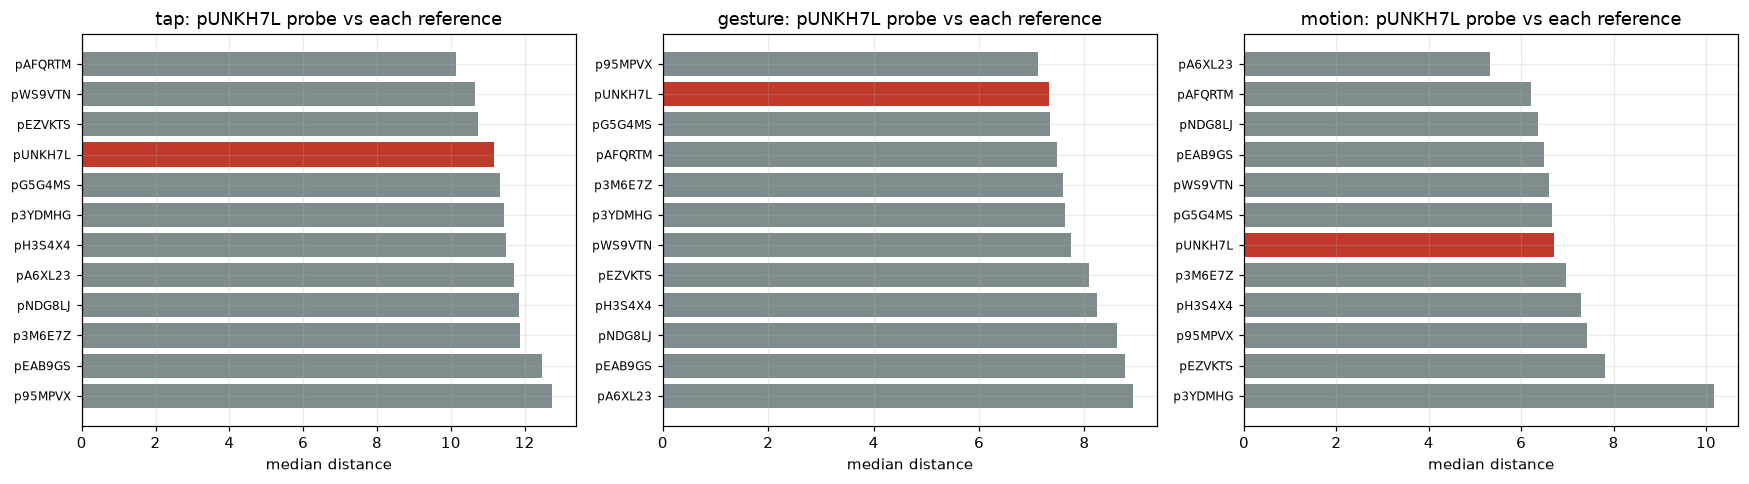

Red = the target's OWN enrolment reference. If red is not leftmost, the inversion is visible here.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, m in zip(axes, ['tap','gesture','motion']):
    sub = scores[m][scores[m]['probe_pid']==TARGET]
    rank = sub.groupby('cand')['dist'].median().sort_values()
    colours = ['#c0392b' if c == TARGET else '#7f8c8d' for c in rank.index]
    ax.barh(range(len(rank)), rank.values, color=colours)
    ax.set_yticks(range(len(rank))); ax.set_yticklabels(rank.index, fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel('median distance'); ax.set_title(f'{m}: {TARGET} probe vs each reference')
plt.tight_layout(); plt.show()
print("Red = the target's OWN enrolment reference. If red is not leftmost, the inversion is visible here.")


## 4. Step change or gradual drift?

The two competing explanations make different predictions.

- A **gradual** within-session/within-sitting drift (fatigue, warming up,
  posture settling) should show distance climbing smoothly with time.
- A **step change** between sessions — consistent within each session but
  different across them — is what you would expect if the *person changed*, or
  if the device was picked up differently for one whole session.

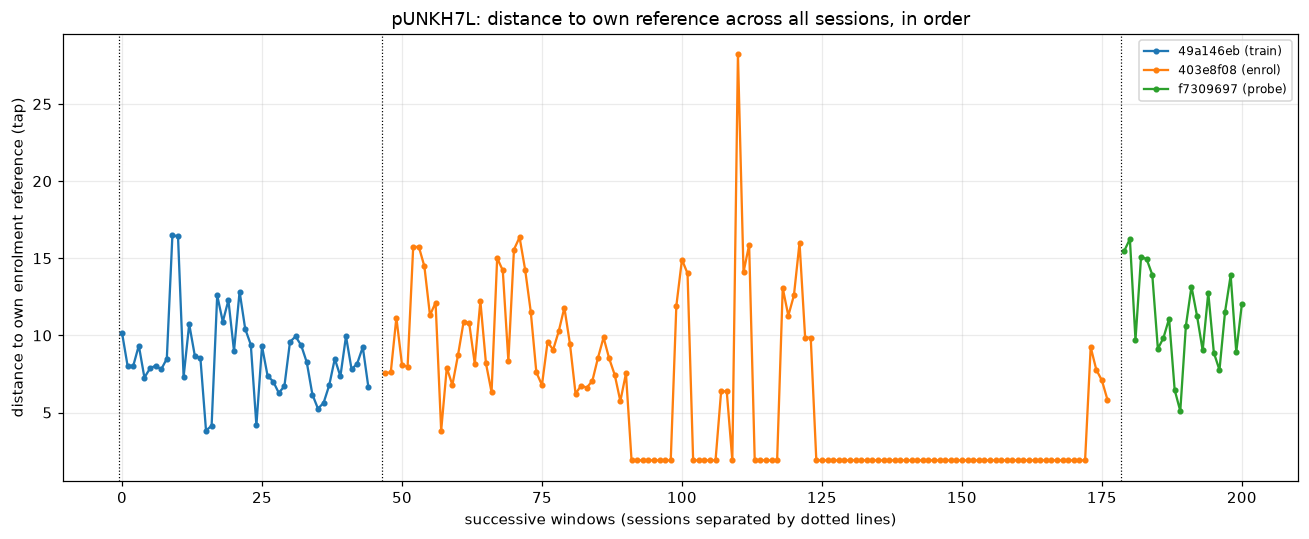

In [12]:
m = 'tap'
df = mods[m]
df = df[(df['deviceFamily']=='mobile')].merge(splits[['sessionId','role']], on='sessionId', how='inner')
feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
feats = [c for c in feats if df[c].notna().mean() >= 0.5]
tr = df[df['role']=='train']; basis = tr if len(tr) >= 30 else df
imp = SimpleImputer(strategy='median').fit(basis[feats]); sc = StandardScaler().fit(imp.transform(basis[feats]))
T = lambda s: sc.transform(imp.transform(s[feats]))

tgt = df[df['participantId']==TARGET].copy()
order = (splits[splits['participantId']==TARGET].sort_values('sessionIndex')['sessionId'].tolist())
enrol_sid = splits[(splits['participantId']==TARGET)&(splits['role']=='enrol')]['sessionId'].iloc[0]
ref = T(tgt[tgt['sessionId']==enrol_sid]).mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
offset = 0
for sid in order:
    g = tgt[tgt['sessionId']==sid].sort_values('window_start_s')
    if not len(g): continue
    d = np.linalg.norm(T(g) - ref, axis=1)
    role = splits[(splits['sessionId']==sid)]['role'].iloc[0]
    x = np.arange(len(d)) + offset
    ax.plot(x, d, marker='o', ms=3, label=f'{sid[:8]} ({role})')
    ax.axvline(offset - 0.5, color='k', ls=':', lw=0.8)
    offset += len(d) + 2
ax.set_xlabel('successive windows (sessions separated by dotted lines)')
ax.set_ylabel(f'distance to own enrolment reference ({m})')
ax.set_title(f'{TARGET}: distance to own reference across all sessions, in order')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 5. Which features moved?

If a small number of features account for the shift, that points at something
specific and possibly mechanical (grip, device orientation). If the shift is
spread across many unrelated features, that is more consistent with a
different person.

In [13]:
enrol_g = tgt[tgt['sessionId']==enrol_sid]
probe_sid = splits[(splits['participantId']==TARGET)&(splits['role']=='probe')]['sessionId'].iloc[0]
probe_g = tgt[tgt['sessionId']==probe_sid]

E, P = T(enrol_g), T(probe_g)
shift = pd.Series(P.mean(axis=0) - E.mean(axis=0), index=feats)
print("Largest standardised shifts between enrolment and probe session (target):")
print(shift.reindex(shift.abs().sort_values(ascending=False).index).head(20).round(2).to_string())

# Same for the control, as a symmetric check -- a large shift is only
# meaningful if the well-behaved participant does not also show one.
ctl = df[df['participantId']==CONTROL]
c_enrol = splits[(splits['participantId']==CONTROL)&(splits['role']=='enrol')]['sessionId'].iloc[0]
c_probe = splits[(splits['participantId']==CONTROL)&(splits['role']=='probe')]['sessionId'].iloc[0]
cE, cP = T(ctl[ctl['sessionId']==c_enrol]), T(ctl[ctl['sessionId']==c_probe])
c_shift = pd.Series(cP.mean(axis=0) - cE.mean(axis=0), index=feats)
print(f"\nMagnitude of enrol->probe shift:  {TARGET} = {np.linalg.norm(shift):.2f}   "
      f"{CONTROL} = {np.linalg.norm(c_shift):.2f}")


Largest standardised shifts between enrolment and probe session (target):
coupling_tap_orient_beta_peak_dev_max       2.43
coupling_tap_orient_beta_peak_dev_std       2.39
coupling_tap_orient_beta_peak_dev_iqr       2.33
coupling_tap_orient_beta_peak_dev_p95       2.09
tap_x_iqr                                   1.54
coupling_tap_accel_impulse_auc_cv           1.33
coupling_tap_orient_beta_peak_dev_median   -1.25
coupling_tap_orient_gamma_peak_dev_max      1.14
tap_x_cv                                    1.11
coupling_tap_orient_gamma_peak_dev_p95      1.10
coupling_tap_orient_beta_peak_dev_mean     -1.07
coupling_tap_accel_z_share_p95             -1.06
coupling_tap_accel_z_share_mean            -1.00
tap_x_std                                   0.96
coupling_tap_accel_z_share_max             -0.89
coupling_tap_accel_z_share_median          -0.89
coupling_tap_orient_gamma_peak_dev_std      0.82
coupling_tap_orient_beta_peak_dev_slope     0.80
coupling_tap_accel_snr_cv                   

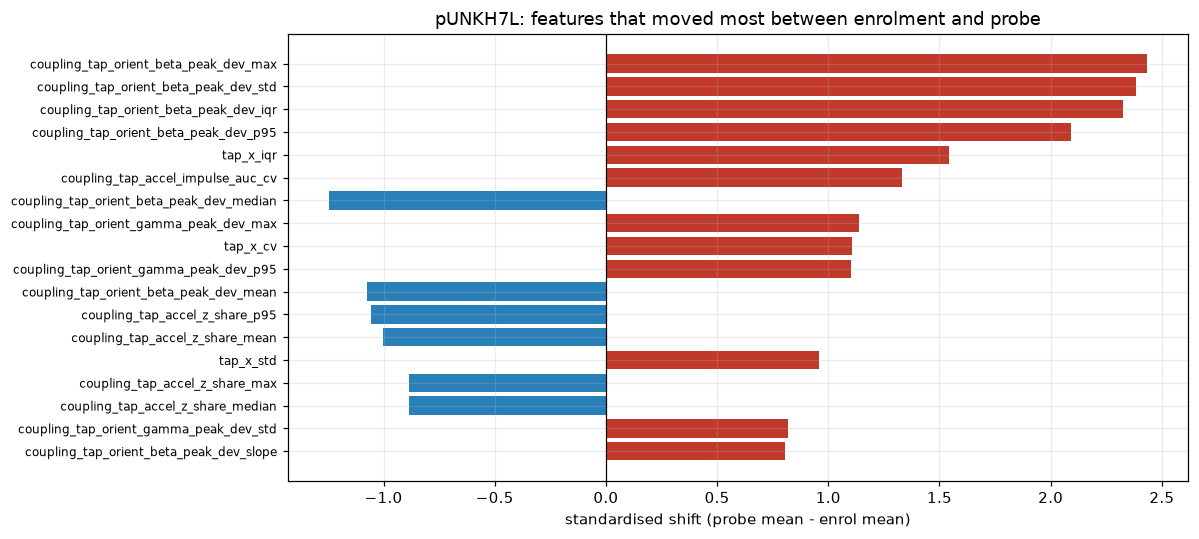

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
top = shift.reindex(shift.abs().sort_values(ascending=False).index).head(18)[::-1]
ax.barh(range(len(top)), top.values, color=['#c0392b' if v>0 else '#2980b9' for v in top.values])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('standardised shift (probe mean - enrol mean)')
ax.set_title(f'{TARGET}: features that moved most between enrolment and probe')
plt.tight_layout(); plt.show()


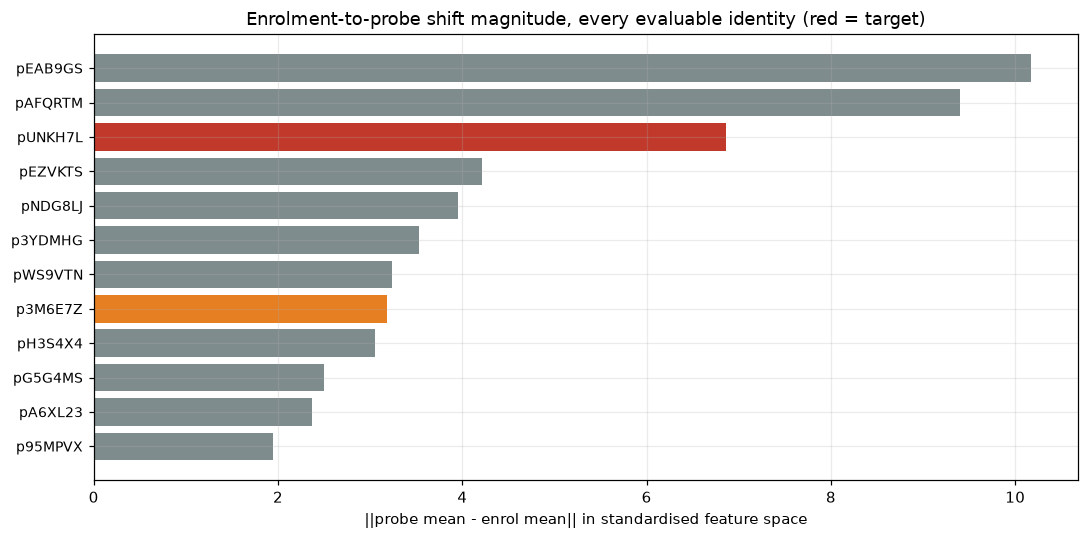

p95MPVX     1.95
pA6XL23     2.37
pG5G4MS     2.50
pH3S4X4     3.05
p3M6E7Z     3.18
pWS9VTN     3.24
p3YDMHG     3.53
pNDG8LJ     3.95
pEZVKTS     4.21
pUNKH7L     6.86
pAFQRTM     9.40
pEAB9GS    10.17


In [15]:
# How unusual is that shift? Compare every evaluable participant's own
# enrol->probe shift magnitude, so the target is placed in context rather
# than judged against an eyeballed threshold.
mags = {}
for pid in splits[splits['evaluable']]['participantId'].unique():
    try:
        e_sid = splits[(splits['participantId']==pid)&(splits['role']=='enrol')]['sessionId'].iloc[0]
        p_sid = splits[(splits['participantId']==pid)&(splits['role']=='probe')]['sessionId'].iloc[0]
    except IndexError:
        continue
    g = df[df['participantId']==pid]
    ge, gp = g[g['sessionId']==e_sid], g[g['sessionId']==p_sid]
    if len(ge) < 3 or len(gp) < 3: continue
    mags[pid] = float(np.linalg.norm(T(gp).mean(axis=0) - T(ge).mean(axis=0)))
mags = pd.Series(mags).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#c0392b' if p == TARGET else ('#e67e22' if p == CONTROL else '#7f8c8d') for p in mags.index]
ax.barh(range(len(mags)), mags.values, color=colours)
ax.set_yticks(range(len(mags))); ax.set_yticklabels(mags.index, fontsize=9)
ax.set_xlabel('||probe mean - enrol mean|| in standardised feature space')
ax.set_title('Enrolment-to-probe shift magnitude, every evaluable identity (red = target)')
plt.tight_layout(); plt.show()
print(mags.round(2).to_string())


## Open questions

- Does the target's shift look like a **step between sessions** (Section 4) or a
  gradual drift within the sitting? The plot answers this directly; the two
  imply different follow-ups.
- Do the moved features (Section 5) cluster into something mechanical — grip,
  contact geometry, device orientation — or are they spread across unrelated
  families?
- Section 1 shows whether any self-reported context field changed between
  sessions. If none did, the benign explanations get harder to sustain.
- If this looks like a genuine second person on the same browser profile, it is
  worth treating as a **case study rather than a defect**: it is the project's
  own threat model appearing unprompted, and the honest framing is that
  `participantId` identifies a browser, not a person.
- Whatever the cause, decide explicitly whether this identity stays in the
  evaluation. Removing it would raise the headline numbers, which is exactly
  why the decision should be made on the evidence here and stated openly,
  not made because it helps.

## 6. Export

Exports this run's findings as structured files, so Gate 4 (nb22) and
the dissertation writeup can pull them directly instead of copying
numbers out of printed notebook output by hand. Filenames are prefixed
with `TARGET` since this notebook is re-run once per flagged participant
(pUNKH7L, pAFQRTM, pEAB9GS) -- same pattern as nb14-17's modality
prefixing, for the same reason (avoid one run's export silently
overwriting another's).


In [16]:
from pathlib import Path
import json as _json
from datetime import datetime, timezone

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    return None

# A bare relative path here was the bug -- if this notebook's own cwd is
# exploratory-notebooks/windows-explorer/ rather than the repo root (which
# is likely, since nb13 lives in a different directory than nb14-22),
# 'data/processed/anomalous_diagnostic' would silently resolve to a
# WRONG, notebook-relative location that Gate 4 (nb22) would never find --
# exactly what happened: table9_gate1_cohort_decision.csv came back with
# every shift_magnitude empty despite this export having run successfully.
# Same find()-based multi-candidate resolution as every other notebook in
# this project (MOD_DIR's own definition, in particular) uses for the same reason.
_data_root = find('data/processed', '../data/processed', '../../data/processed',
                   '../../../data/processed')
if _data_root is None:
    raise FileNotFoundError(
        "Could not locate data/processed from this notebook's cwd -- checked "
        "up to 3 parent directories. Adjust the find() candidates above if the "
        "repo is nested differently.")
OUT_DIR = Path(_data_root) / 'anomalous_diagnostic'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Exporting to: {OUT_DIR.resolve()}")

# 1. Shift magnitude across ALL evaluable identities -- the same full
# list regardless of which TARGET this run used, so exporting it once
# per run is redundant but harmless (last run's export will just overwrite
# with an identical table, unless the underlying data changed).
mags.rename('shift_magnitude').reset_index().rename(columns={'index': 'participantId'}).to_csv(
    OUT_DIR / 'all_identities_shift_magnitude.csv', index=False)

# 2. Per-modality rank of TARGET among all candidates (own rank + full ranking)
rank_rows = []
for m in ['tap', 'gesture', 'motion']:
    sub = scores[m][scores[m]['probe_pid'] == TARGET]
    rank = sub.groupby('cand')['dist'].median().sort_values()
    own_rank = list(rank.index).index(TARGET) + 1
    for pos, (cand, dist) in enumerate(rank.items(), start=1):
        rank_rows.append({'modality': m, 'target': TARGET, 'candidate': cand,
                           'rank': pos, 'median_dist': float(dist),
                           'is_target_own_reference': cand == TARGET,
                           'target_own_rank': own_rank, 'n_candidates': len(rank)})
pd.DataFrame(rank_rows).to_csv(OUT_DIR / f'{TARGET}_modality_ranks.csv', index=False)

# 3. Feature-level shift for TARGET (enrol -> probe, standardised space)
shift.rename('standardised_shift').reset_index().rename(columns={'index': 'feature'}).sort_values(
    'standardised_shift', key=abs, ascending=False).to_csv(OUT_DIR / f'{TARGET}_feature_shift.csv', index=False)

# 4. Context questionnaire values for TARGET and CONTROL, across their own sessions
ctx_export_cols = ['sessionId', 'participantId', 'ctxPosture', 'ctxHandUse', 'ctxMovement',
                    'ctxFatigue', 'ctxFocusLevel', 'ctxEnvironmentNoise', 'ctxPrivacy',
                    'ctxTimeOfDay', 'deviceModel']
sess_ctx[sess_ctx['participantId'].isin([TARGET, CONTROL])][ctx_export_cols].to_csv(
    OUT_DIR / f'{TARGET}_context_questionnaire.csv', index=False)

# 5. Small manifest tying this run's key numbers together
manifest_path = OUT_DIR / f'{TARGET}_manifest.json'
manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'target': TARGET, 'control': CONTROL,
    'shift_magnitude': float(mags.get(TARGET, float('nan'))),
    'shift_magnitude_rank': int(mags.rank(ascending=False).get(TARGET, float('nan'))),
    'n_evaluable_identities': len(mags),
    'own_rank_by_modality': {m: int(pd.DataFrame(rank_rows)[
        (pd.DataFrame(rank_rows)['modality'] == m)]['target_own_rank'].iloc[0])
        for m in ['tap', 'gesture', 'motion']},
    'top_shifted_features': shift.reindex(shift.abs().sort_values(ascending=False).index).head(10).to_dict(),
}
with open(manifest_path, 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)

print(f"Wrote to {OUT_DIR.resolve()}:")
for p in sorted(OUT_DIR.glob(f'{TARGET}*')) + [OUT_DIR / 'all_identities_shift_magnitude.csv']:
    if p.exists():
        print(f"  {p.name}")


Exporting to: /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/anomalous_diagnostic
Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/anomalous_diagnostic:
  pUNKH7L_context_questionnaire.csv
  pUNKH7L_feature_shift.csv
  pUNKH7L_manifest.json
  pUNKH7L_modality_ranks.csv
  all_identities_shift_magnitude.csv
